Aditya Nautiyal
24CH10038
KodeinKGP Sophomore Selection Task


Overview: 
This dataset simulates anonymized e-commerce customer session logs and is designed for binary classification: predicting whether a customer will make a purchase during their session.
Target Variable:
Purchase (0 = No, 1 = Yes)
Features:
1)Time_on_site (float):
Time (in minutes) the customer spent on the website during the session.
2)Pages_viewed (float):
Approximate number of pages visited in the session.
3)Clicked_ad (binary):
Indicates whether the user clicked on a product advertisement.
Values: 0 (No), 1 (Yes)
4)Cart_value (float):
Total value of products in the user's cart during the session (in USD).
May contain zeros (for those who did not add to cart).
5)Referral (categorical):
Source from where the user was referred.
6)Values: Google, Facebook, Instagram, Direct
7)Browser_Refresh_Rate (float):
A synthetic distracting feature simulating technical metrics.
8)Last_Ad_Seen (categorical):
The name of the last ad campaign seen by the user.
Values: “A”, “B”, “C”, “D”



In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_test=pd.read_csv(r'C:\Users\Aditya\Downloads\customer_behavior_test.csv')
df_train=pd.read_csv(r"C:\Users\Aditya\Downloads\customer_behavior_train.csv")
df_train.columns = df_train.columns.str.strip()
df_test.columns = df_test.columns.str.strip()
print(df_train.info())
print('______________________________________________')
print(df_train.describe())
print('______________________________________________')
print(df_train.isnull().sum())
print('______________________________________________')
print(df_train['Purchase'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Time_on_site          1800 non-null   float64
 1   Pages_viewed          1800 non-null   float64
 2   Clicked_ad            1800 non-null   int64  
 3   Cart_value            1800 non-null   float64
 4   Referral              1800 non-null   object 
 5   Browser_Refresh_Rate  1800 non-null   float64
 6   Last_Ad_Seen          1800 non-null   object 
 7   Purchase              1800 non-null   int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 112.6+ KB
None
______________________________________________
       Time_on_site  Pages_viewed   Clicked_ad   Cart_value  \
count   1800.000000   1800.000000  1800.000000  1800.000000   
mean       4.962244     12.429483     0.301111    50.352933   
std        2.336373      6.381941     0.458868    47.443390   
min        0.500

In [3]:
df_train['Browser_Refresh_Rate'] = df_train['Browser_Refresh_Rate'].apply(lambda x: abs(x))
df_test['Browser_Refresh_Rate'] = df_test['Browser_Refresh_Rate'].apply(lambda x: abs(x))



In [4]:
df_train

,Time_on_site,Pages_viewed,Clicked_ad,Cart_value,Referral,Browser_Refresh_Rate,Last_Ad_Seen,Purchase
0,2.29,5.37,1,10.00,Facebook,143.14,D,1
1,7.49,16.36,0,25.52,Instagram,136.66,A,1
2,5.71,13.69,0,10.00,Google,67.13,C,0
3,1.23,3.22,1,41.49,Google,92.12,C,0
4,3.55,10.72,0,21.57,Direct,70.31,B,0
...,...,...,...,...,...,...,...,...
1795,4.99,11.27,0,53.20,Facebook,90.52,B,0
1796,3.92,8.20,0,46.06,Google,85.45,A,0
1797,4.63,8.95,0,38.75,Google,99.26,D,0
1798,7.90,23.95,0,70.82,Google,153.03,D,1


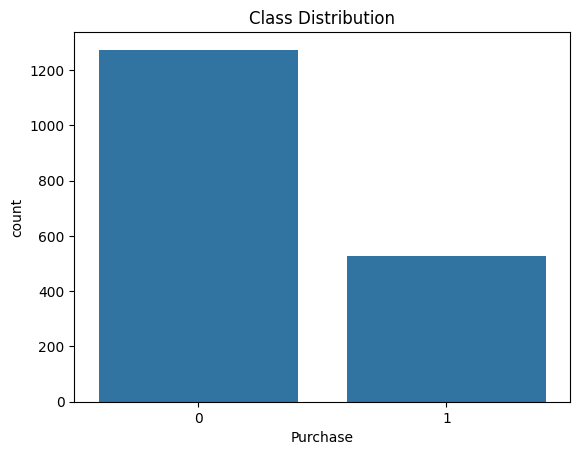

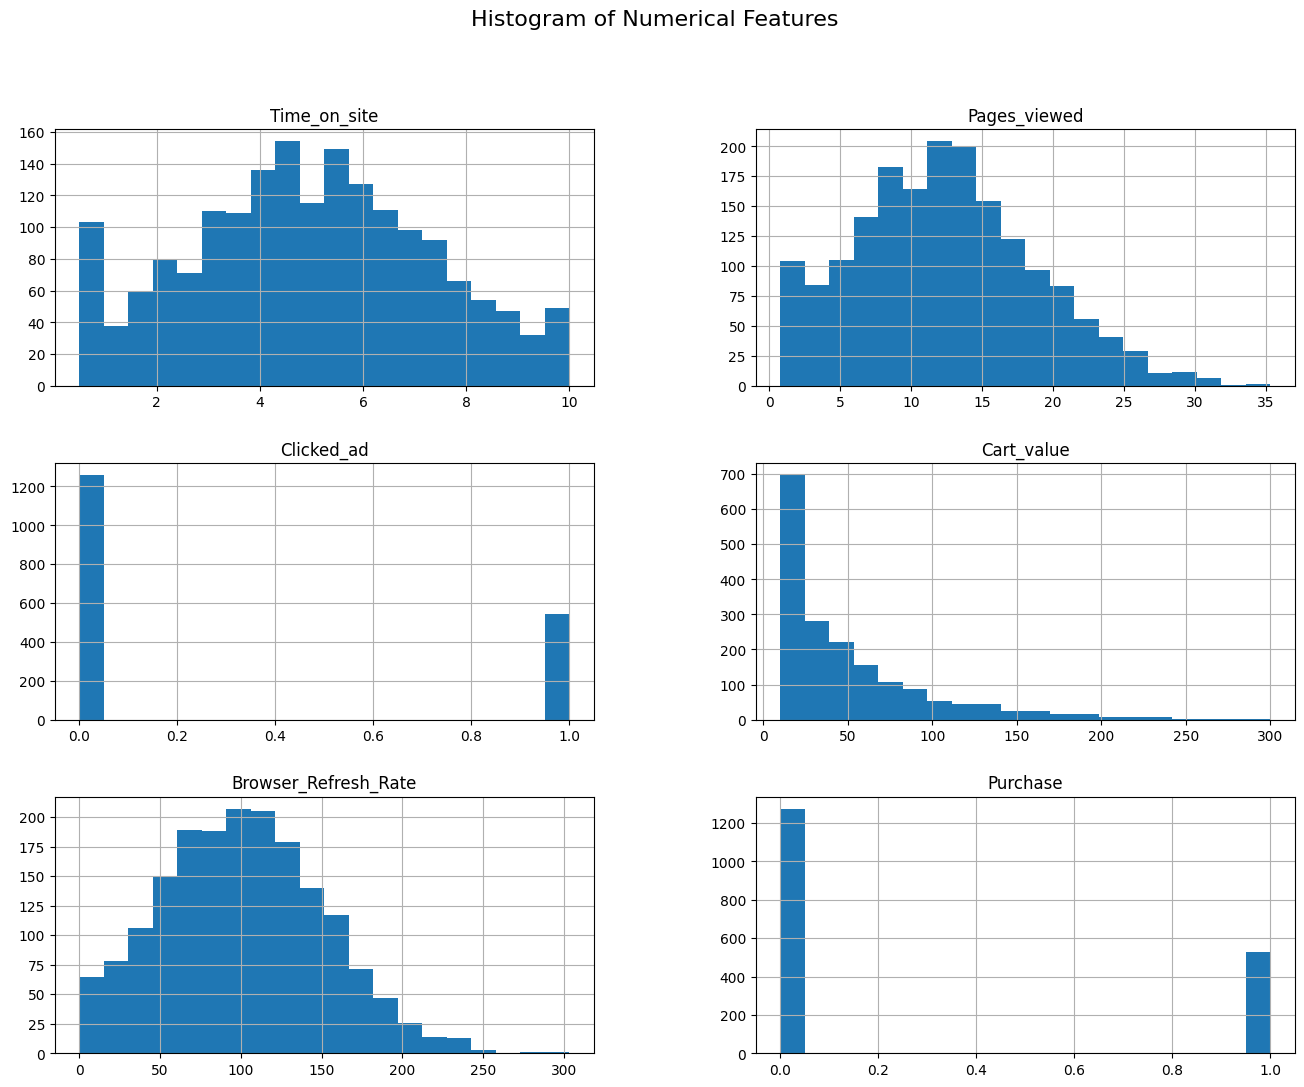

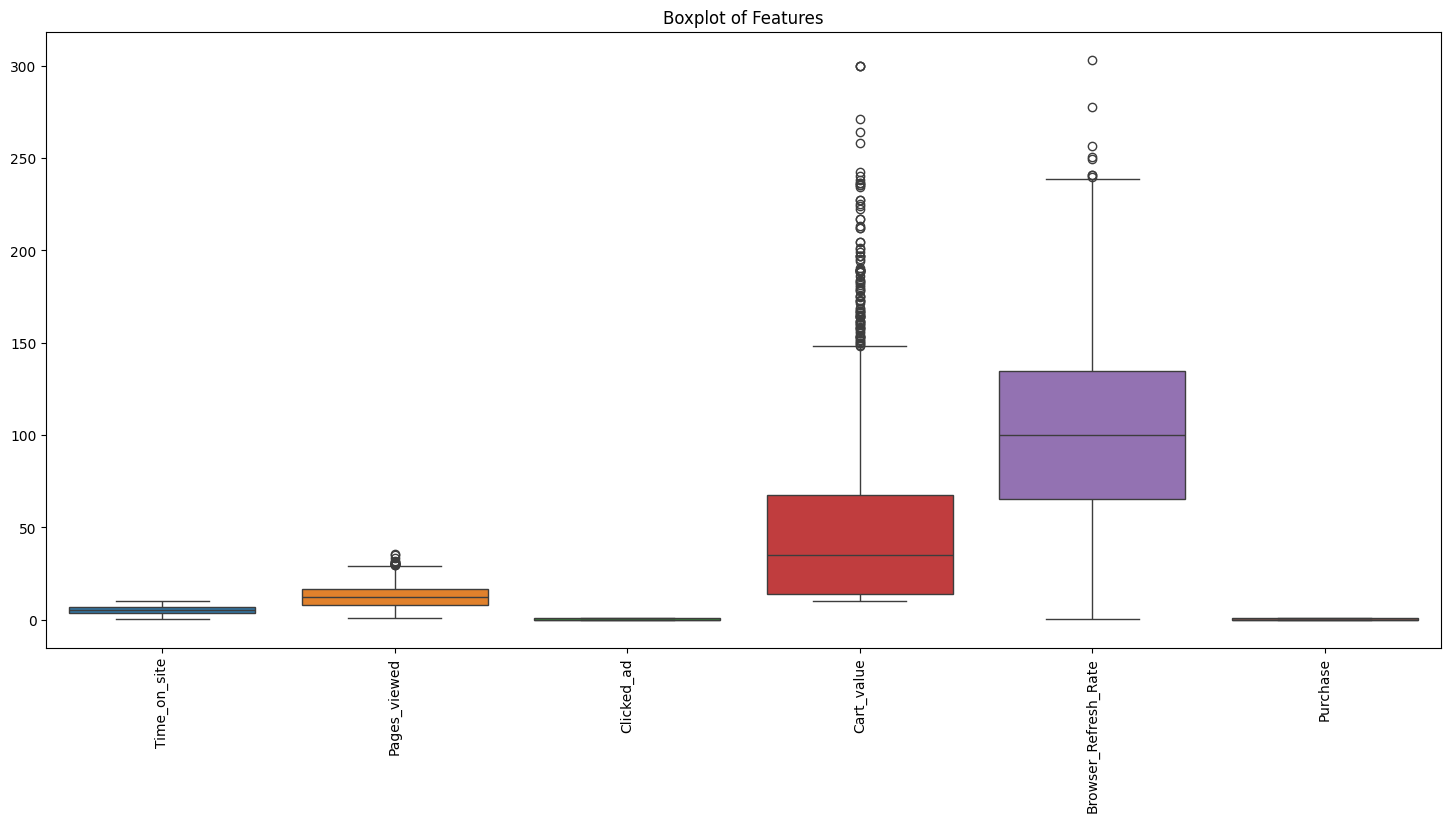

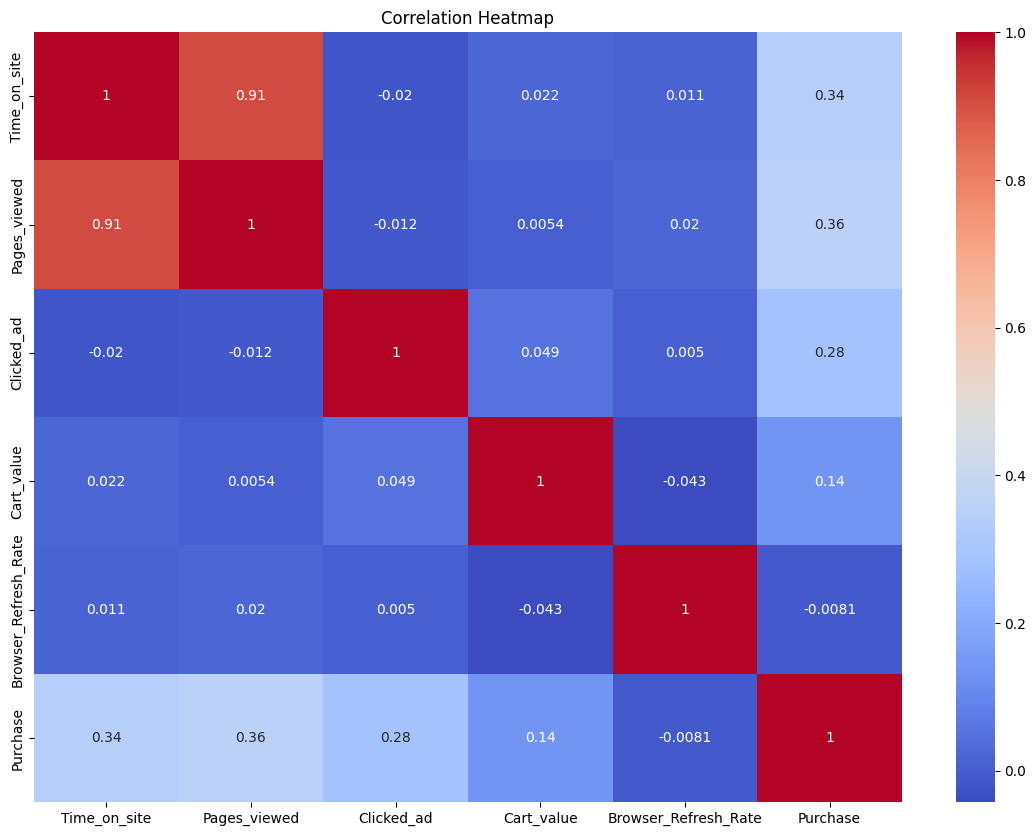

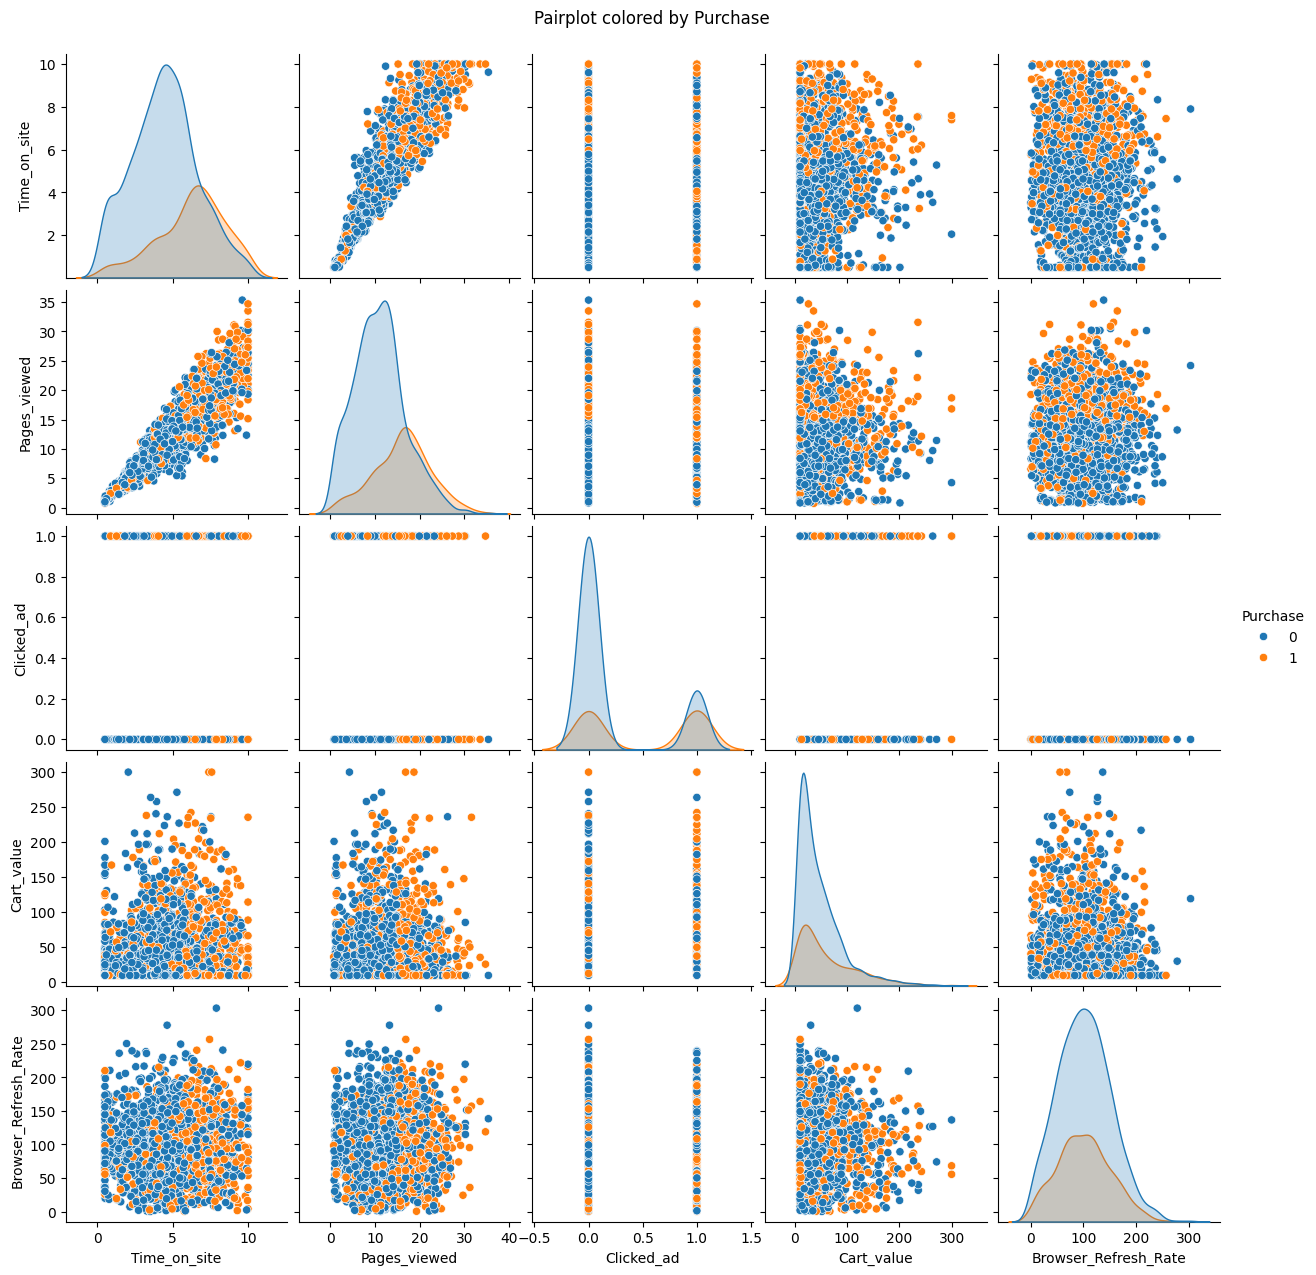

In [5]:
sns.countplot(x='Purchase', data=df_train)
plt.title("Class Distribution")
plt.show()

df_train.hist(bins=20, figsize=(16, 12))
plt.suptitle("Histogram of Numerical Features", fontsize=16)
plt.show()

plt.figure(figsize=(18, 8))
sns.boxplot(data=df_train.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title("Boxplot of Features")
plt.show()

plt.figure(figsize=(14, 10))
numeric=[i for i in df_train.columns  if df_train[i].dtype!='O']
sns.heatmap(df_train[numeric].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

sns.pairplot(data=df_train, hue='Purchase')
plt.suptitle("Pairplot colored by Purchase", y=1.02)
plt.show()


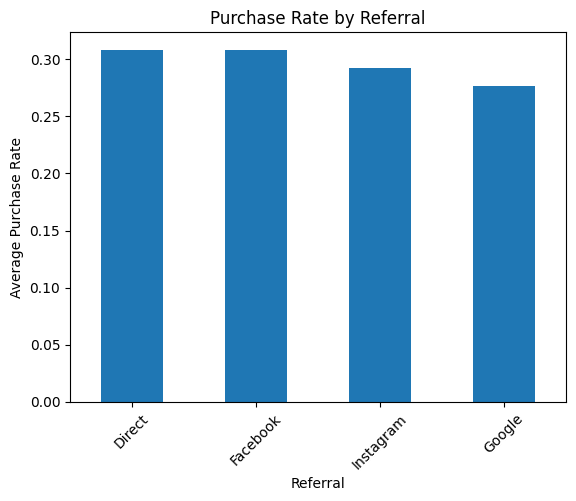

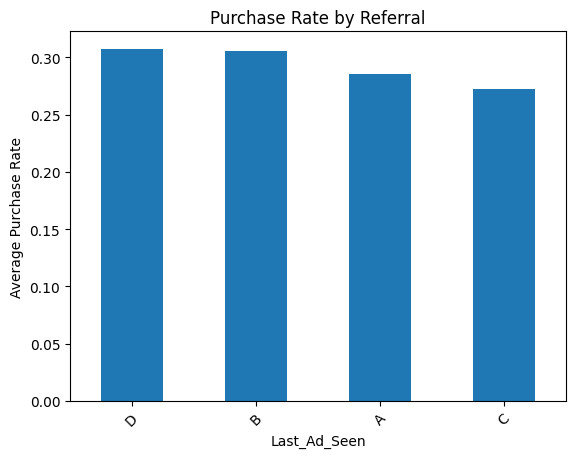

In [6]:
# Example for 'Referral'
df_train.groupby("Referral")["Purchase"].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Purchase Rate by Referral")
plt.ylabel("Average Purchase Rate")
plt.xticks(rotation=45)
plt.show()

df_train.groupby("Last_Ad_Seen")["Purchase"].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Purchase Rate by Referral")
plt.ylabel("Average Purchase Rate")
plt.xticks(rotation=45)
plt.show()



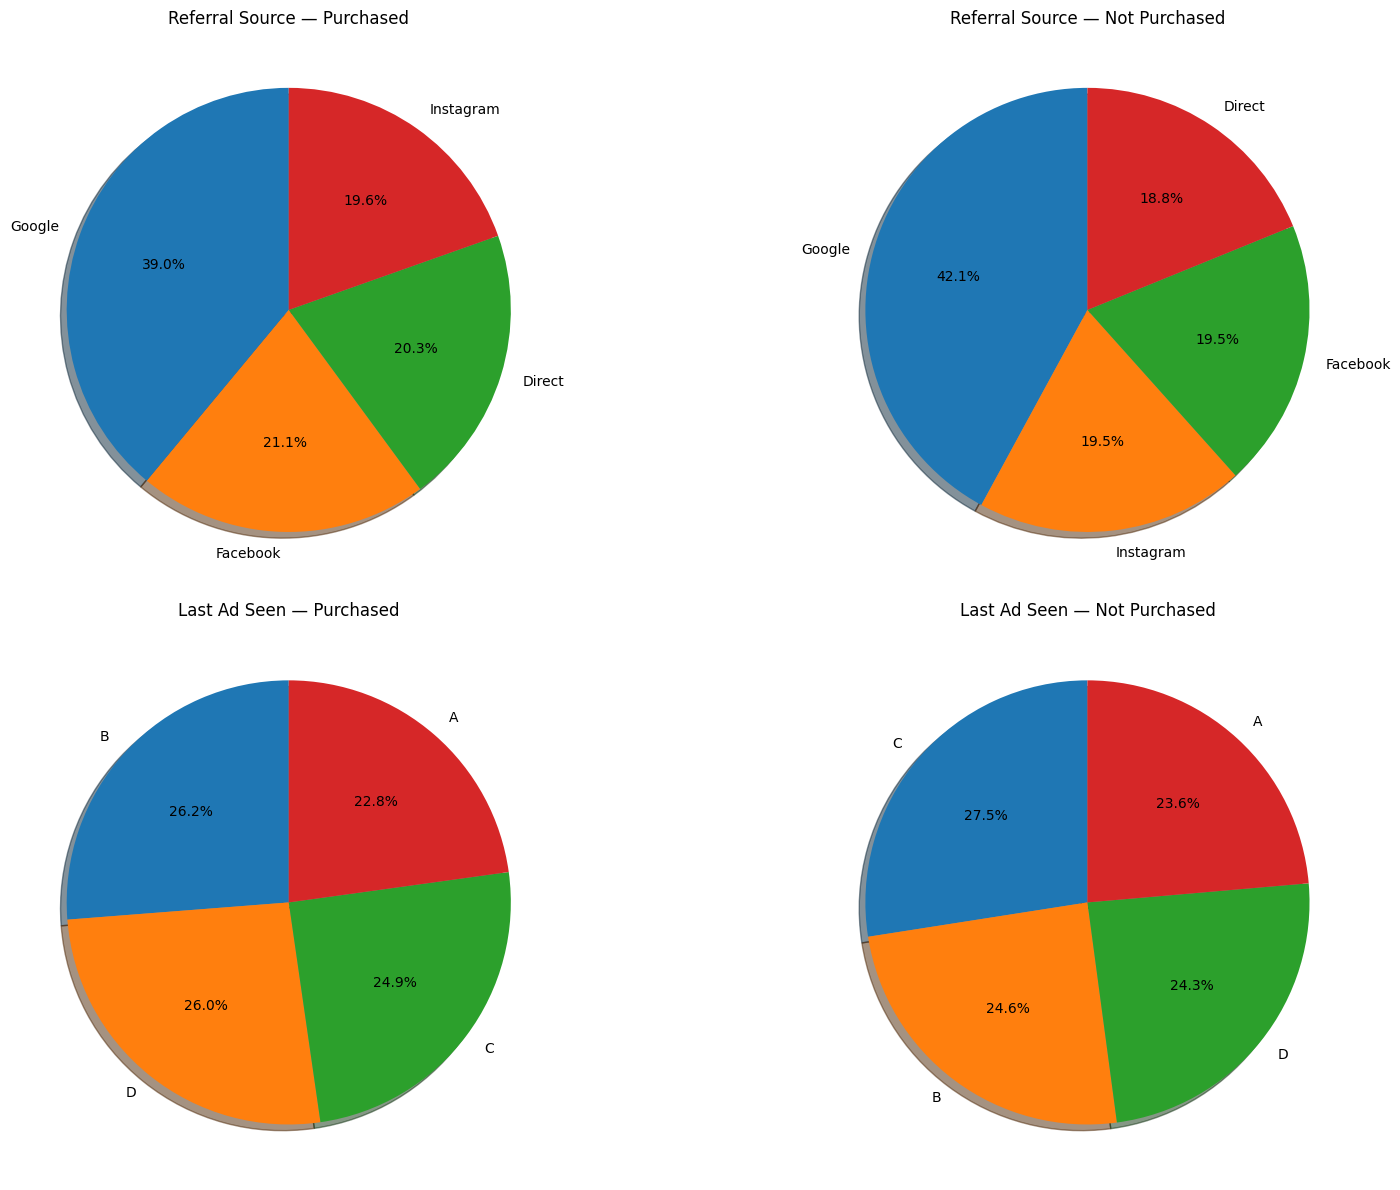

In [7]:
# Aggregate purchases
referral_purchases_yes = df_train[df_train['Purchase'] == 1]['Referral'].value_counts()
referral_purchases_no = df_train[df_train['Purchase'] == 0]['Referral'].value_counts()
ad_purchases_yes = df_train[df_train['Purchase'] == 1]['Last_Ad_Seen'].value_counts()
ad_purchases_no = df_train[df_train['Purchase'] == 0]['Last_Ad_Seen'].value_counts()


fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Pie Chart 1: Referral - Purchased
axes[0, 0].pie(referral_purchases_yes, labels=referral_purchases_yes.index,
               autopct='%1.1f%%', startangle=90,shadow=True)
axes[0, 0].set_title('Referral Source — Purchased')

# Pie Chart 2: Referral - Not Purchased
axes[0, 1].pie(referral_purchases_no, labels=referral_purchases_no.index,
               autopct='%1.1f%%', startangle=90,shadow=True)
axes[0, 1].set_title('Referral Source — Not Purchased')

# Pie Chart 3: Last Ad Seen — Purchased
axes[1, 0].pie(ad_purchases_yes, labels=ad_purchases_yes.index,
               autopct='%1.1f%%', startangle=90,shadow=True)
axes[1, 0].set_title('Last Ad Seen — Purchased')

# Pie Chart 4: Last Ad Seen — Not Purchased
axes[1, 1].pie(ad_purchases_no, labels=ad_purchases_no.index,
               autopct='%1.1f%%', startangle=90,shadow=True)
axes[1, 1].set_title('Last Ad Seen — Not Purchased')


plt.tight_layout()
plt.show()



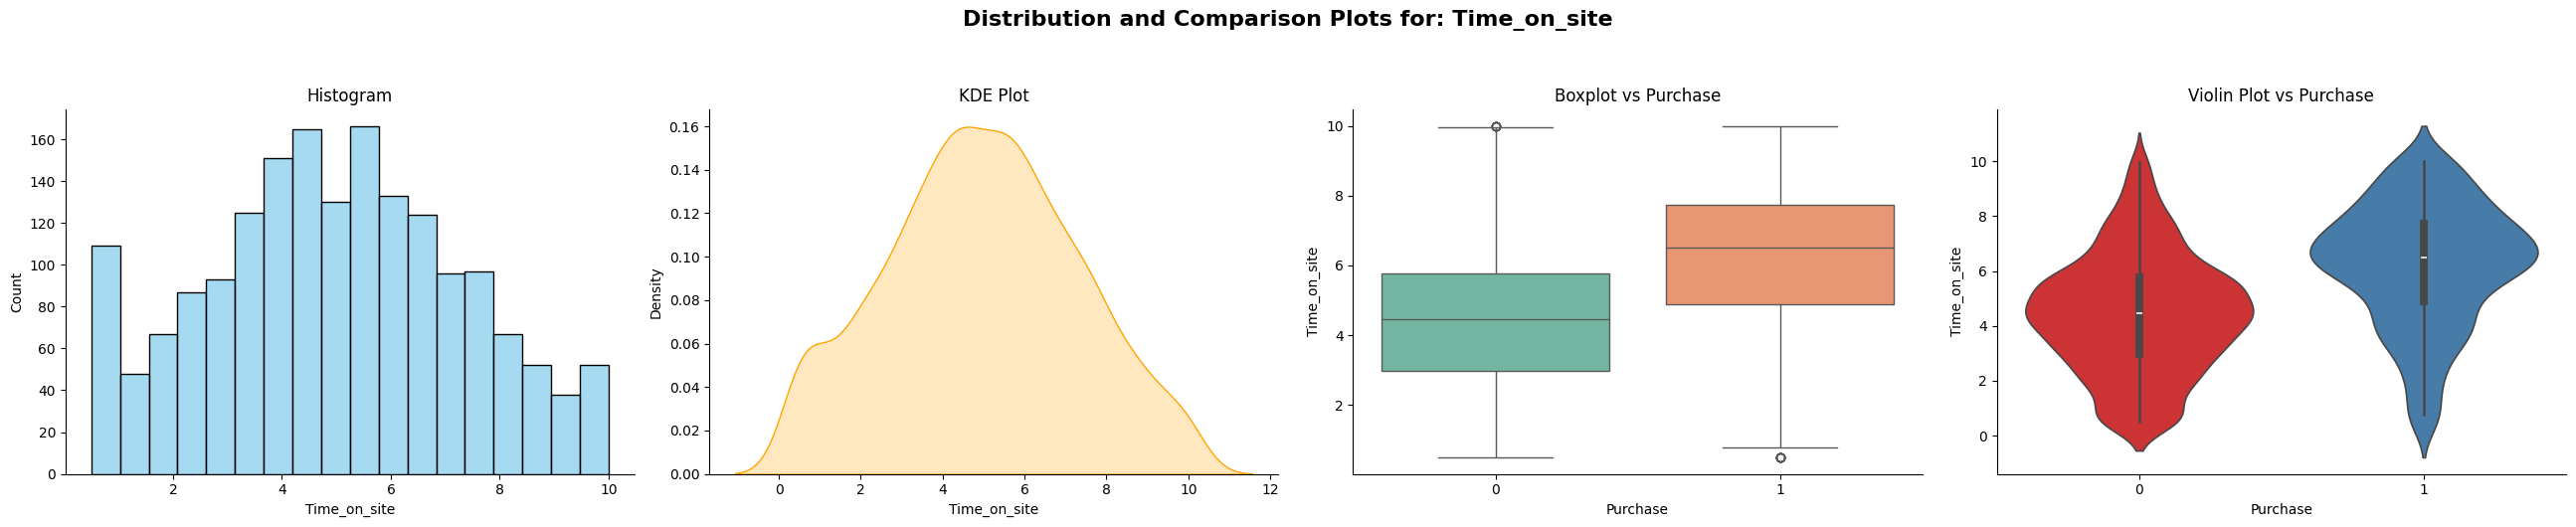

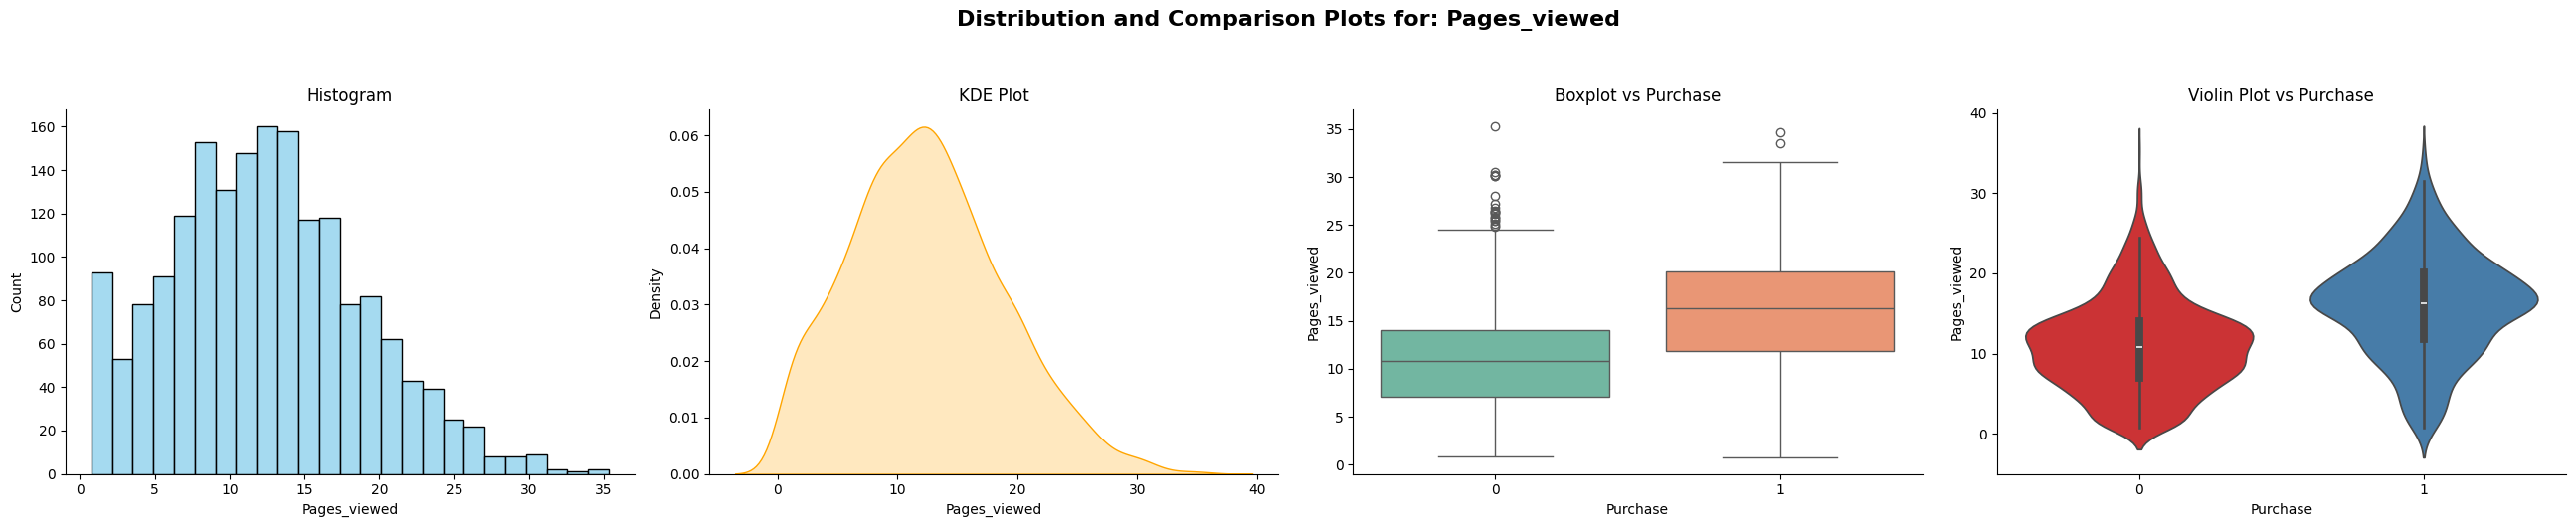

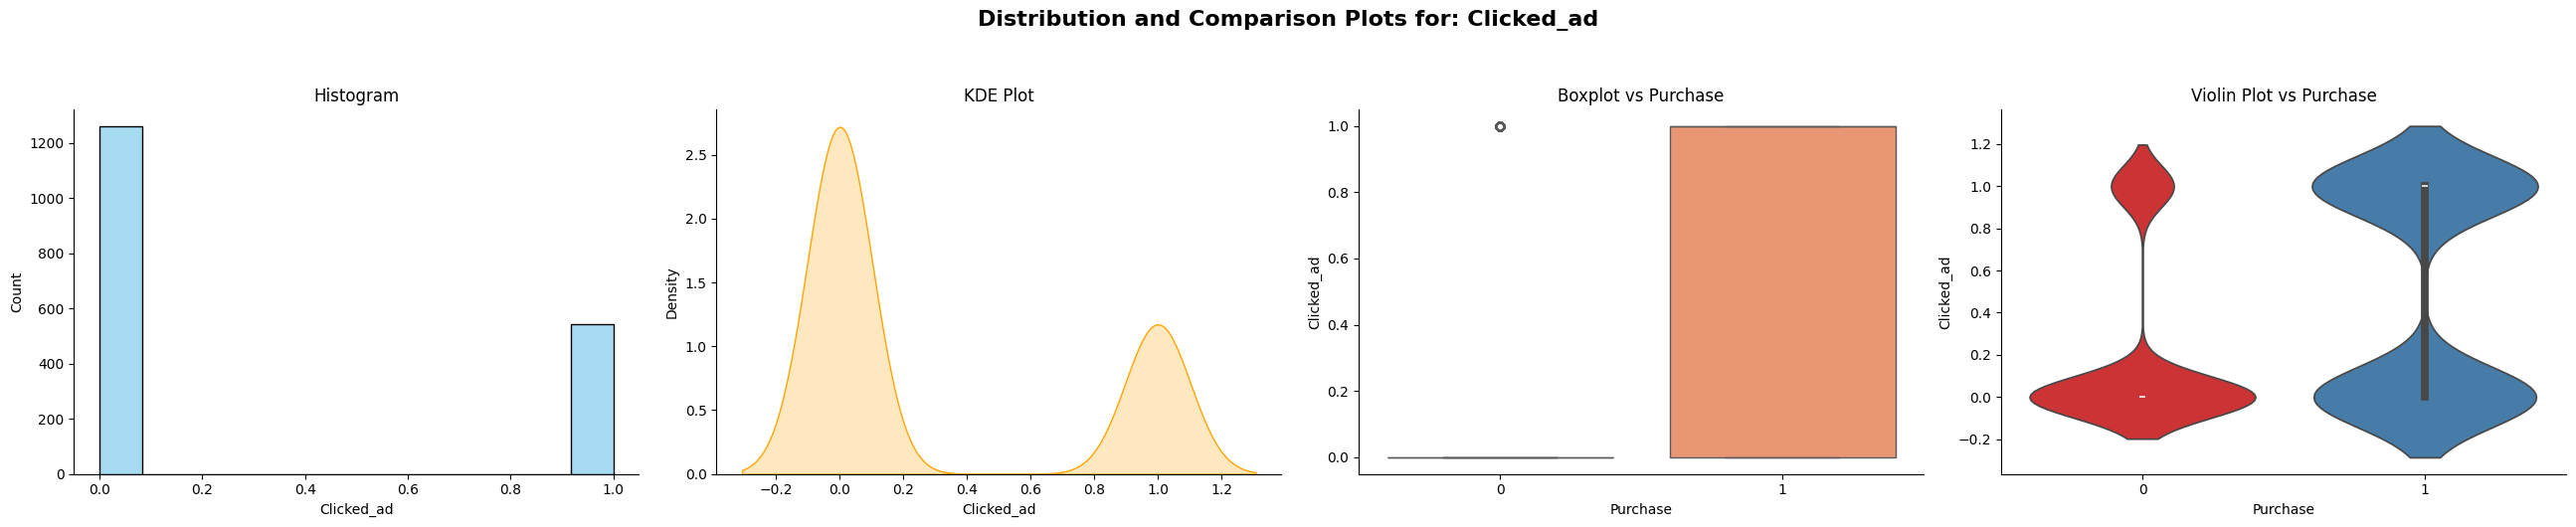

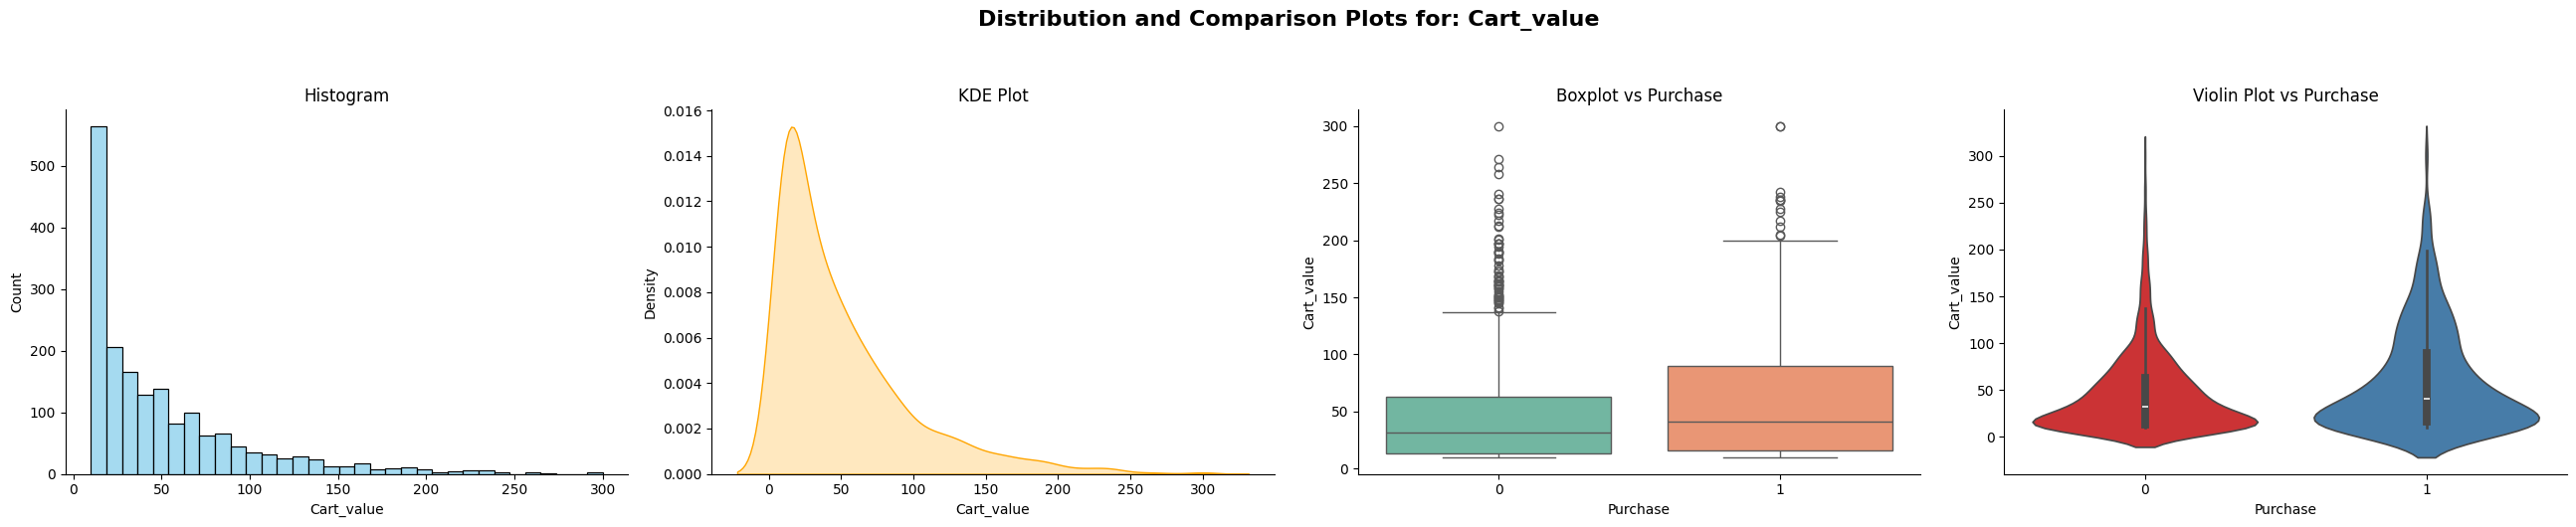

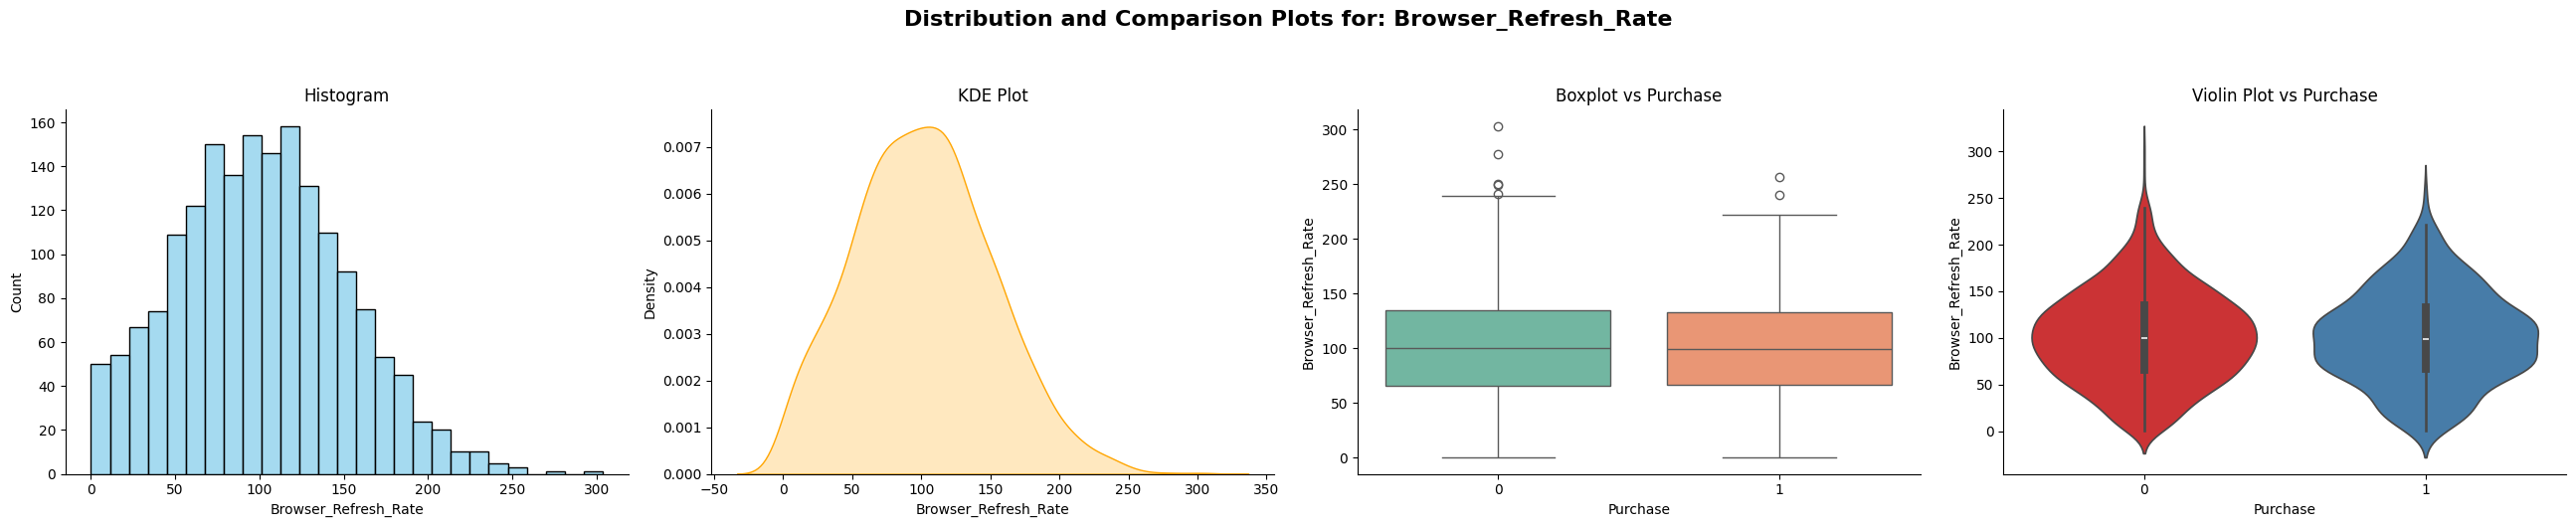

In [9]:
# Select numerical features only
numerical_cols = [i for i in df_train.columns if df_train[i].dtypes!='O']
numerical_cols.remove("Purchase")  

for col in numerical_cols:
    fig, axs = plt.subplots(1, 4, figsize=(26, 5))
    fig.suptitle(f'Distribution and Comparison Plots for: {col}', fontsize=16, fontweight='bold', y=1.05)

    # Histogram
    sns.histplot(df_train[col], kde=False, ax=axs[0], color='skyblue')
    axs[0].set_title('Histogram')
    axs[0].spines['top'].set_visible(False)
    axs[0].spines['right'].set_visible(False)

    # KDE Plot
    sns.kdeplot(df_train[col], ax=axs[1], fill=True, color='orange')
    axs[1].set_title('KDE Plot')
    axs[1].spines['top'].set_visible(False)
    axs[1].spines['right'].set_visible(False)

    # Boxplot by Purchase
    sns.boxplot(x='Purchase', y=col, data=df_train, ax=axs[2], palette='Set2')
    axs[2].set_title('Boxplot vs Purchase')
    axs[2].spines['top'].set_visible(False)
    axs[2].spines['right'].set_visible(False)

    # Violin plot by Purchase
    sns.violinplot(x='Purchase', y=col, data=df_train, ax=axs[3], palette='Set1')
    axs[3].set_title('Violin Plot vs Purchase')
    axs[3].spines['top'].set_visible(False)
    axs[3].spines['right'].set_visible(False)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85) 
    plt.show()


In [10]:
## Here tried to convert categorial to numerical ,but at the end efficiency is higher for not considering categorial columns

'''from sklearn.preprocessing import OneHotEncoder


encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_train = encoder.fit_transform(df_train[['Referral', 'Last_Ad_Seen']])
encoded_test = encoder.transform(df_test[['Referral', 'Last_Ad_Seen']])

encoded_train_df = pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(['Referral', 'Last_Ad_Seen']))
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(['Referral', 'Last_Ad_Seen']))

df_train = pd.concat([df_train, encoded_train_df], axis=1)
df_test = pd.concat([df_test, encoded_test_df], axis=1)  '''

df_train = df_train.drop(['Referral', 'Last_Ad_Seen'], axis=1).reset_index(drop=True)
df_test = df_test.drop(['Referral', 'Last_Ad_Seen'], axis=1).reset_index(drop=True)

X_train=df_train.drop(('Purchase'),axis=1)
y_train=df_train.loc[:,'Purchase']
X_test=df_test.drop(('Purchase'),axis=1)
y_test=df_test.loc[:,'Purchase']


In [11]:
df_test.head()

,Time_on_site,Pages_viewed,Clicked_ad,Cart_value,Browser_Refresh_Rate,Purchase
0,3.33,12.76,0,27.66,131.60,0
1,3.75,10.20,0,15.05,41.63,0
2,6.55,16.40,0,105.27,98.72,1
3,6.42,19.68,1,21.17,180.20,0
4,8.38,30.59,0,91.31,58.70,1


Best params: {'poly__degree': 2, 'lg__solver': 'saga', 'lg__penalty': 'l1', 'lg__class_weight': 'balanced', 'lg__C': 0.05}
Best CV accuracy: 0.7283333333333333
accuracy_score 75.1111111111111
classification_report
              precision    recall  f1-score   support

           0       0.89      0.74      0.81       314
           1       0.56      0.78      0.65       136

    accuracy                           0.75       450
   macro avg       0.72      0.76      0.73       450
weighted avg       0.79      0.75      0.76       450

Confusion Matrix
[[232  30]
 [ 82 106]]
F1 score: 0.654320987654321
roc_auc_score 0.8349334956912701


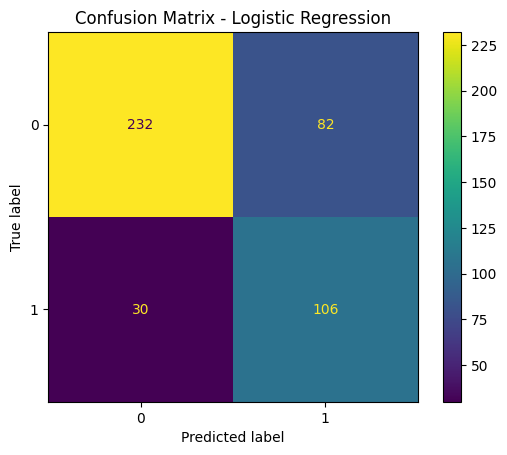

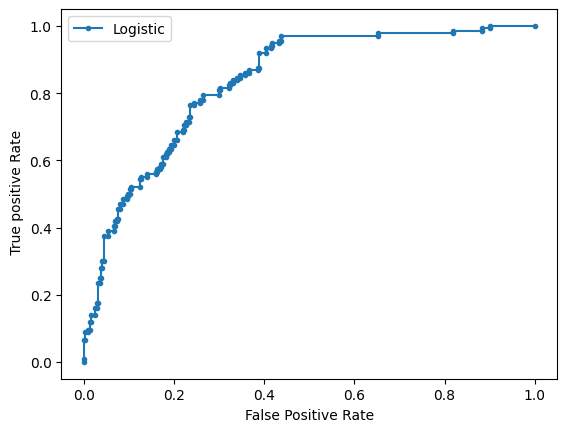

In [12]:
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.model_selection import RandomizedSearchCV,StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
scaler=StandardScaler()
lg=LogisticRegression(max_iter=5000)
pip=Pipeline([
    ('poly',PolynomialFeatures(include_bias=True)),
    ('scaler',scaler),
    ('lg',lg),
])

param_grid = [{
    'poly__degree': [1, 2],
    'lg__penalty': ['l1', 'l2'],
    'lg__solver': ['liblinear', 'saga'],
    'lg__C': [0.05, 0.1, 0.5, 1, 5],
    'lg__class_weight': ["balanced"]}
]
grid=RandomizedSearchCV(n_iter=40,random_state=42,estimator=pip,param_distributions=param_grid,cv=StratifiedKFold(n_splits=5),scoring='accuracy',n_jobs=-1,refit=True)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

y_pred=grid.predict(X_test)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve,f1_score
print('accuracy_score',accuracy_score(y_pred,y_test)*100)
print('classification_report')
print(classification_report(y_test,y_pred))
print('Confusion Matrix')
print(confusion_matrix(y_pred,y_test))
print('F1 score:',f1_score(y_test,y_pred))
print('roc_auc_score',roc_auc_score(y_test,grid.predict_proba(X_test)[:, 1]))
model_fpr,model_tpr,thresholds=roc_curve(y_test,grid.predict_proba(X_test)[:, 1])


from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(grid.best_estimator_, X_test, y_test)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

plt.plot(model_fpr,model_tpr,marker='.',label="Logistic")
plt.xlabel("False Positive Rate")
plt.ylabel(" True positive Rate")
plt.legend()
plt.show()


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'svc__kernel': 'rbf', 'svc__gamma': 0.1, 'svc__class_weight': None, 'svc__C': 1}
Best CV accuracy: 0.7683333333333333
accuracy_score 75.1111111111111
classification_report
              precision    recall  f1-score   support

           0       0.89      0.74      0.81       314
           1       0.56      0.78      0.65       136

    accuracy                           0.75       450
   macro avg       0.72      0.76      0.73       450
weighted avg       0.79      0.75      0.76       450

Confusion Matrix
[[232  30]
 [ 82 106]]
F1 score: 0.654320987654321
roc_auc_score 0.8219019295616335


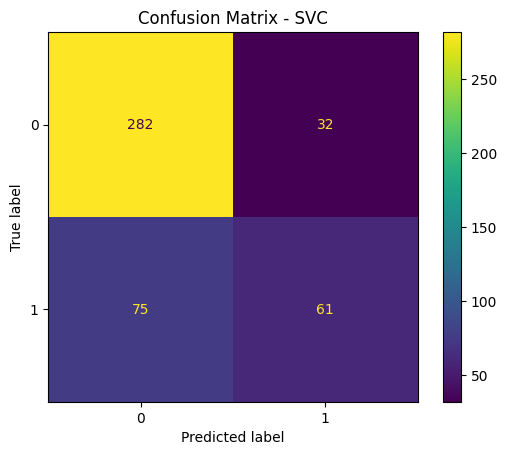

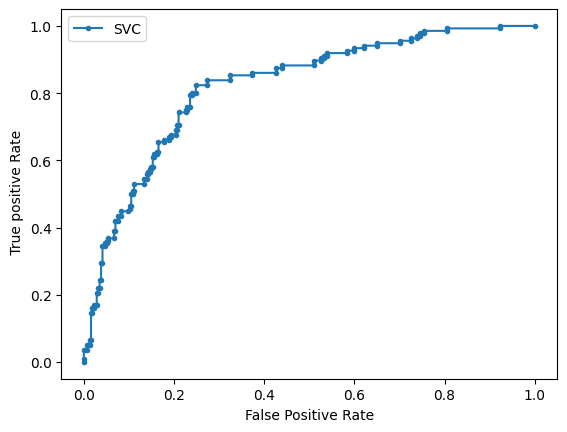

In [16]:

from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV,StratifiedKFold
svc=SVC(probability=True)
pip=Pipeline([
    ('scaler',scaler),
    ('svc',svc )])
param_dist={
    'svc__C': [0.1, 1, 10, 100, 1000],
    'svc__gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'svc__kernel': ['rbf', 'poly'],
    'svc__class_weight': [None, 'balanced']
}
grid=RandomizedSearchCV(n_iter=20,random_state=42,estimator=pip,scoring='accuracy',refit=True,param_distributions=param_dist,cv=StratifiedKFold(5),verbose=3,n_jobs=-1)
grid.fit(X_train,y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)


print('accuracy_score',accuracy_score(y_pred,y_test)*100)
print('classification_report')
print(classification_report(y_test,y_pred))
print('Confusion Matrix')
print(confusion_matrix(y_pred,y_test))
print('F1 score:',f1_score(y_test,y_pred))
print('roc_auc_score',roc_auc_score(y_test,grid.predict_proba(X_test)[:, 1]))
model_fpr,model_tpr,thresholds=roc_curve(y_test,grid.predict_proba(X_test)[:, 1])

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(grid.best_estimator_, X_test, y_test)
plt.title("Confusion Matrix - SVC")
plt.show()
plt.plot(model_fpr,model_tpr,marker='.',label="SVC")
plt.xlabel("False Positive Rate")
plt.ylabel(" True positive Rate")
plt.legend()
plt.show()